# 02 - Entrenamiento y comparación de modelos

## Objetivo

Entrenar los cinco algoritmos solicitados, compararlos con las mismas métricas
y seleccionar el mejor según ROC-AUC.

## 1. Importaciones y configuración

In [1]:
import os
import sys
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score, roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

RUTA_PROYECTO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(RUTA_PROYECTO / "src"))

from data_loader import cargar_datos, dividir_datos

RUTA_DATASET = RUTA_PROYECTO / "data" / "dataset_practica_final.csv"
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 2. Carga, limpieza y división

In [2]:
df_reservas, X, y, numero_duplicados = cargar_datos(RUTA_DATASET)

(X_train, X_validacion, X_test,
 y_train, y_validacion, y_test) = dividir_datos(X, y, RANDOM_STATE)

print(f"Duplicados eliminados: {numero_duplicados:,}")
print(f"Train: {len(X_train):,} filas")
print(f"Validación: {len(X_validacion):,} filas")
print(f"Test: {len(X_test):,} filas")

Duplicados eliminados: 31,994
Train: 61,177 filas
Validación: 13,109 filas
Test: 13,110 filas


Las columnas `reservation_status` y `reservation_status_date` se eliminan en
`data_loader.py` porque contienen información posterior a la cancelación.
La división estratificada mantiene una proporción parecida de cancelaciones en
los tres conjuntos.

## 3. Preprocesamiento

In [3]:
columnas_identificadores = [
    columna for columna in ["agent", "company"] if columna in X.columns
]
columnas_numericas = [
    columna for columna in X.select_dtypes(include=["number", "bool"]).columns
    if columna not in columnas_identificadores
]
columnas_categoricas = (
    X.select_dtypes(exclude=["number", "bool"]).columns.tolist()
    + columnas_identificadores
)

transformador_numerico = Pipeline([
    ("imputacion", SimpleImputer(strategy="median", add_indicator=True)),
    ("escalado", StandardScaler())
])

transformador_categorico = Pipeline([
    ("imputacion", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer([
    ("numericas", transformador_numerico, columnas_numericas),
    ("categoricas", transformador_categorico, columnas_categoricas)
])

X_train_preparado = preprocesador.fit_transform(X_train)
X_validacion_preparado = preprocesador.transform(X_validacion)
X_test_preparado = preprocesador.transform(X_test)

print("Dimensión después del preprocesamiento:", X_train_preparado.shape)

Dimensión después del preprocesamiento: (61177, 866)


El preprocesamiento se ajusta únicamente con `train`. Los números se imputan
con la mediana y se escalan; las categorías se imputan con la moda y se
convierten mediante One-Hot Encoding.

## 4. Función común de evaluación

In [4]:
def calcular_metricas(nombre_modelo, y_real, y_pred, y_probabilidad):
    return {
        "modelo": nombre_modelo,
        "accuracy": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, zero_division=0),
        "recall": recall_score(y_real, y_pred, zero_division=0),
        "f1": f1_score(y_real, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_real, y_probabilidad)
    }

resultados = []
probabilidades_validacion = {}
modelos_entrenados = {}

## 5. Regresión logística

In [5]:
modelo_regresion = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
modelo_regresion.fit(X_train_preparado, y_train)

y_pred_regresion = modelo_regresion.predict(X_validacion_preparado)
y_prob_regresion = modelo_regresion.predict_proba(X_validacion_preparado)[:, 1]

resultados.append(calcular_metricas(
    "Regresión logística", y_validacion, y_pred_regresion, y_prob_regresion
))
probabilidades_validacion["Regresión logística"] = y_prob_regresion
modelos_entrenados["Regresión logística"] = modelo_regresion
pd.Series(resultados[-1])

modelo       Regresión logística
accuracy                0.809749
precision               0.696391
recall                   0.54606
f1                      0.612131
roc_auc                 0.868521
dtype: object

## 6. Árbol de decisión

In [6]:
modelo_arbol = DecisionTreeClassifier(
    max_depth=12, min_samples_leaf=20,
    class_weight="balanced", random_state=RANDOM_STATE
)
modelo_arbol.fit(X_train_preparado, y_train)

y_pred_arbol = modelo_arbol.predict(X_validacion_preparado)
y_prob_arbol = modelo_arbol.predict_proba(X_validacion_preparado)[:, 1]

resultados.append(calcular_metricas(
    "Árbol de decisión", y_validacion, y_pred_arbol, y_prob_arbol
))
probabilidades_validacion["Árbol de decisión"] = y_prob_arbol
modelos_entrenados["Árbol de decisión"] = modelo_arbol
pd.Series(resultados[-1])

modelo       Árbol de decisión
accuracy              0.779083
precision             0.564978
recall                0.854051
f1                    0.680071
roc_auc               0.880905
dtype: object

## 7. Random Forest

In [7]:
modelo_random_forest = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=5,
    class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
)
modelo_random_forest.fit(X_train_preparado, y_train)

y_pred_random_forest = modelo_random_forest.predict(X_validacion_preparado)
y_prob_random_forest = modelo_random_forest.predict_proba(X_validacion_preparado)[:, 1]

resultados.append(calcular_metricas(
    "Random Forest", y_validacion, y_pred_random_forest, y_prob_random_forest
))
probabilidades_validacion["Random Forest"] = y_prob_random_forest
modelos_entrenados["Random Forest"] = modelo_random_forest
pd.Series(resultados[-1])

modelo       Random Forest
accuracy          0.782363
precision         0.570464
recall            0.843507
f1                0.680622
roc_auc           0.889441
dtype: object

## 8. XGBoost

In [8]:
modelo_xgboost = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE
)
modelo_xgboost.fit(X_train_preparado, y_train)

y_pred_xgboost = modelo_xgboost.predict(X_validacion_preparado)
y_prob_xgboost = modelo_xgboost.predict_proba(X_validacion_preparado)[:, 1]

resultados.append(calcular_metricas(
    "XGBoost", y_validacion, y_pred_xgboost, y_prob_xgboost
))
probabilidades_validacion["XGBoost"] = y_prob_xgboost
modelos_entrenados["XGBoost"] = modelo_xgboost
pd.Series(resultados[-1])

modelo        XGBoost
accuracy     0.845679
precision    0.761668
recall       0.638457
f1           0.694642
roc_auc      0.914563
dtype: object

## 9. Red neuronal multicapa con Keras

In [9]:
X_train_red = X_train_preparado.toarray()
X_validacion_red = X_validacion_preparado.toarray()
X_test_red = X_test_preparado.toarray()

tf.keras.utils.set_random_seed(RANDOM_STATE)

modelo_red = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train_red.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu", name="h1"),
    tf.keras.layers.Dropout(0.20),
    tf.keras.layers.Dense(64, activation="relu", name="h2"),
    tf.keras.layers.Dropout(0.10),
    tf.keras.layers.Dense(1, activation="sigmoid", name="salida")
])

modelo_red.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=3, restore_best_weights=True
)

history = modelo_red.fit(
    X_train_red, y_train,
    validation_split=0.15,
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=0
)

y_prob_red = modelo_red.predict(X_validacion_red, verbose=0).ravel()
y_pred_red = (y_prob_red >= 0.5).astype(int)

resultados.append(calcular_metricas(
    "Red neuronal Keras", y_validacion, y_pred_red, y_prob_red
))
probabilidades_validacion["Red neuronal Keras"] = y_prob_red
modelos_entrenados["Red neuronal Keras"] = modelo_red
pd.Series(resultados[-1])

modelo       Red neuronal Keras
accuracy               0.847814
precision              0.722668
recall                 0.724473
f1                     0.723569
roc_auc                0.912272
dtype: object

## 10. Comparación final en validación

In [10]:
tabla_resultados = (
    pd.DataFrame(resultados)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)
tabla_resultados.round(3)

,modelo,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.846,0.762,0.638,0.695,0.915
1,Red neuronal Keras,0.848,0.723,0.724,0.724,0.912
2,Random Forest,0.782,0.570,0.844,0.681,0.889
3,Árbol de decisión,0.779,0.565,0.854,0.680,0.881
4,Regresión logística,0.810,0.696,0.546,0.612,0.869


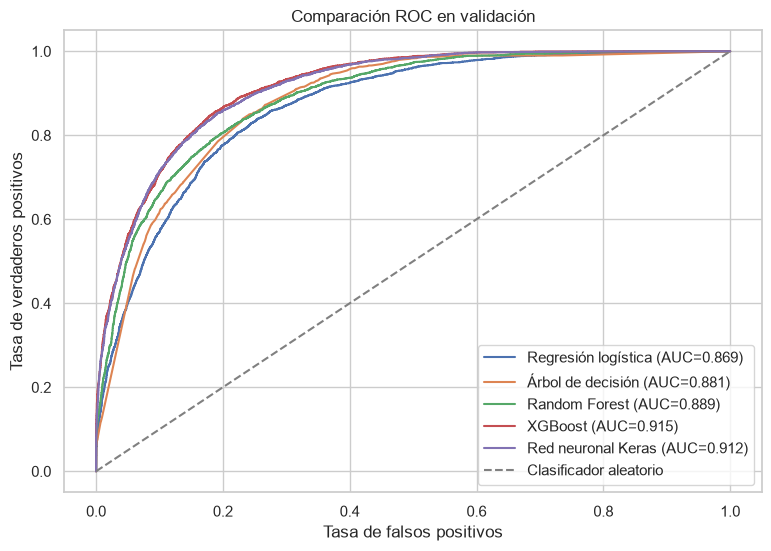

In [11]:
plt.figure(figsize=(9, 6))

for nombre_modelo, probabilidades in probabilidades_validacion.items():
    tasa_fp, tasa_vp, _ = roc_curve(y_validacion, probabilidades)
    auc_modelo = roc_auc_score(y_validacion, probabilidades)
    plt.plot(tasa_fp, tasa_vp, label=f"{nombre_modelo} (AUC={auc_modelo:.3f})")

plt.plot([0, 1], [0, 1], "--", color="grey", label="Clasificador aleatorio")
plt.title("Comparación ROC en validación")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend(loc="lower right")
plt.show()

## 11. Evaluación del ganador en test

In [12]:
nombre_mejor_modelo = tabla_resultados.iloc[0]["modelo"]
mejor_modelo = modelos_entrenados[nombre_mejor_modelo]

if nombre_mejor_modelo == "Red neuronal Keras":
    y_prob_test = mejor_modelo.predict(X_test_red, verbose=0).ravel()
    y_pred_test = (y_prob_test >= 0.5).astype(int)
else:
    y_prob_test = mejor_modelo.predict_proba(X_test_preparado)[:, 1]
    y_pred_test = mejor_modelo.predict(X_test_preparado)

metricas_test = calcular_metricas(
    nombre_mejor_modelo, y_test, y_pred_test, y_prob_test
)

print("Modelo seleccionado:", nombre_mejor_modelo)
pd.Series(metricas_test)

Modelo seleccionado: XGBoost


modelo        XGBoost
accuracy     0.843402
precision    0.755856
recall       0.635683
f1            0.69058
roc_auc       0.90931
dtype: object

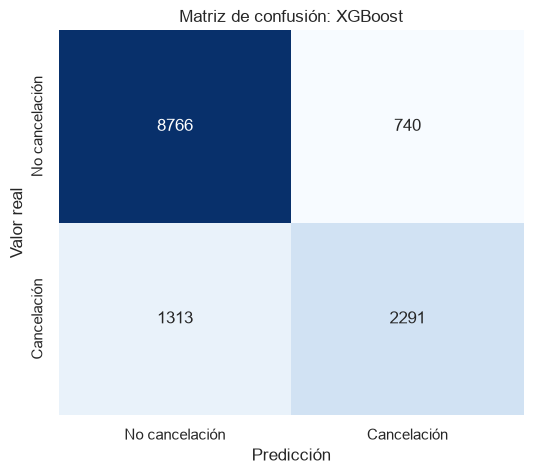

In [13]:
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["No cancelación", "Cancelación"],
    yticklabels=["No cancelación", "Cancelación"]
)
plt.title(f"Matriz de confusión: {nombre_mejor_modelo}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## Conclusiones

- Se comparan los cinco modelos con el mismo conjunto de validación.
- ROC-AUC es la métrica principal porque existe desbalance y no depende de un
  único umbral.
- El conjunto de test solo se utiliza después de seleccionar el ganador.
- Si el negocio priorizase detectar más cancelaciones, habría que revisar el
  umbral y observar especialmente el recall.